In [ ]:
# import packages 
import pandas as pd 
import numpy as np
import sweetviz as sv

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Exploratory Data Analysis

In [2]:
# load the file and find relevant summaries 
response = pd.read_csv('/Users/diyapatel/Documents/GitHub/Advanced-ML/Midterm Exam Take Home/midterm_train.csv')
response.head()
response.info()
response.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         32950 non-null  int64  
 1   customer_age               32950 non-null  int64  
 2   occupation_type            32950 non-null  object 
 3   relationship_status        32950 non-null  object 
 4   education_background       32950 non-null  object 
 5   has_credit_issue           32950 non-null  object 
 6   mortgage_status            32950 non-null  object 
 7   personal_loan_status       32950 non-null  object 
 8   last_contact_month         32950 non-null  object 
 9   day_of_week                32950 non-null  object 
 10  contact_time_minutes       32950 non-null  int64  
 11  contact_attempt_count      32950 non-null  int64  
 12  days_since_prior_contact   32950 non-null  int64  
 13  prior_contact_count        32950 non-null  int

,id,customer_age,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,20612.919423,40.016813,257.355387,2.556601,961.748892,0.173445,0.077132,93.574951,-40.508273,3.614729,5166.787681,0.112747,0.136510,0.037511
std,11872.660725,10.421766,256.687433,2.751165,188.697125,0.496422,1.572468,0.579559,4.628221,1.737144,72.459588,0.316288,0.343334,0.190014
min,0.000000,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000
25%,10373.250000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000,0.000000
50%,20610.500000,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000,0.000000
75%,30858.750000,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000,0.000000
max,41187.000000,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000,1.000000


In [3]:
# initial EDA using sweetviz
report = sv.analyze(response)
report.show_html('sweet_report.html')  

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweet_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### EDA Insights and Summaries 
Based on the initial EDA looking into the plots created by SweetViz, a few insights were identified that directly affected my modeling decisions: 

1. Class imbalance with the target variable (accepted_offer): Only 11.3% of the customer interactions resulted in an accepted offer, and 88.7% were rejected. The skewness in the data shows that basic accuracy could be a misleading metric, and to address this in modeling, stratify=y will split the data and preserve the class ratios.

2. Right-Skewed distributions: Customer engagement features like contact_time_minutes and contact_attempt_count showed to have heavy right-skewed distributions. In modeling, this can cause biases so transformations to these numeric features must be used 

3. Many "unknown" variables: Categorical variables such as education_background and mortgage_status, which can cause an overfitted model if not handled properly. 

4. High cardinality in categorical data: Dataset relies on categorical data, so there also needs to be a handling of categorical variables, espeically for models without native categorical handling. Maybe One-Hot encoding or CountFrequencyEncoder can be used to represent categories.


## Data Preparation

### Show the preprocessing steps used for modeling

In [ ]:
# import relevant data preparation packages 
import pandas as pd 
import numpy as np 
import catboost as cb 
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import optuna

In [5]:
# replace missing values like "Unknown"
# visuals showed no missing values, but keeping this just in case
response = response.replace("unknown", np.nan)

# convert binary categorical to 0/1
if "has_credit_issue" in response.columns:
    response["has_credit_issue"] = response["has_credit_issue"].apply(lambda x: 1 if x == "yes" else 0) 

In [6]:
# splitting data into train and test sets 
# separate features x, and target y
X = response.drop(['accepted_offer', 'id'], axis=1)
y = response['accepted_offer']

# train test split 
# stratify = y to prevent the class imbalance from skewing the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42) 


In [ ]:
# Identify all columns in training data that are of type 'object'
categorical_cols = X_train.select_dtypes(include=['object']).columns

In [8]:
# CatBoost: Convert all object columns to 'category' type 
X_train[categorical_cols] = X_train[categorical_cols].astype('category')
X_test[categorical_cols] = X_test[categorical_cols].astype('category')

# list of cat_features to use later 
catboost_features_list = categorical_cols

In [9]:
# RandomForestClassifier: Numeric --> One-Hot Encoding 
# pd.get_dummies to convert categories into binary 0/1 columns
X_train_rf = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_rf = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)


### Data Preparation Steps and Summaries 

I followed this workflow to handle missingness and categorical variables, so I can prepare my baseline models for feature engineering: 

1. Handling Missingness: Many of the categories had "unknown". They were first converted to NaN values to properly track missing data. Then during feature engineering the NaN values were filled with "Unknown" so models can use it as its own category rather than dropping the rows completely. 

2. Handling Categorical Features: 
- Binary Mapping: Binary categorical variables, such as has_credit_issue were mapped to numeric 0/1 indicators. 
- CatBoost: Categorical columns were converted to the category type through Pandas as CatBoost already has a useful native categorical handling of the data. 
- Random Forest: To prepare RandomForestClassifer for the baseline modeling, categorical variables were transformed using one-hot encoding through pd.get_dummies to create binary columns. 

## Feature Engineering

In [10]:
pip install feature-engine


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
# install feature engineering packages 
from feature_engine.transformation import YeoJohnsonTransformer
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder

# create a copy of the dataset
df_fe = response.copy()

# identify categorical and numerical columns to transform
cat_cols = [
    'occupation_type', 'relationship_status', 'education_background', 'mortgage_status', 'personal_loan_status', 
    'last_contact_month', 'day_of_week', 'prior_outcome_status'
]

# targeting numeric variables that showed to be right-skewed
num_cols = ["contact_time_minutes", "contact_attempt_count"]

# fill in missing categorical values 
df_fe[cat_cols] = df_fe[cat_cols].fillna("Unknown")

# transform skewed numeric features with YeoJohnson
yj = YeoJohnsonTransformer(variables=num_cols)
df_fe = yj.fit_transform(df_fe)

# group the rare categories 
rare = RareLabelEncoder(tol=0.01, variables=cat_cols)
df_fe = rare.fit_transform(df_fe)

# frequency encode categorical variables 
freq = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
df_fe = freq.fit_transform(df_fe)
print("Example after feature-engine transformations + encoding:")
print(df_fe[num_cols + cat_cols[:3]].head())

Example after feature-engine transformations + encoding:
   contact_time_minutes  contact_attempt_count  occupation_type  \
0              8.294950               0.468848         0.096571   
1              7.352309               0.607065         0.252989   
2              8.684215               0.468848         0.034385   
3              7.702248               0.607065         0.252989   
4             10.679612               0.468848         0.252989   

   relationship_status  education_background  
0             0.603612              0.230926  
1             0.603612              0.296571  
2             0.603612              0.230926  
3             0.282822              0.296571  
4             0.603612              0.042671  


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable relationship_status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable education_background is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable mortgage_status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/s

In [12]:
# define x and y on the df copy 
X = df_fe.drop(columns=["accepted_offer", "id"])
y = df_fe["accepted_offer"]

# extract train and test sets using the fixed training set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# setup cross validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
# Baseline CatBoost Model 
# omit cat-features since df_fe is now all numeric from feature-engine
cb_model = cb.CatBoostClassifier(random_state=42,
auto_class_weights="Balanced", 
verbose=False)

# cross validation
cb_cv_scores = cross_val_score(cb_model, X_train, y_train, cv=kf, scoring="accuracy")
print(f"\nCatBoost CV Accuracy: {cb_cv_scores.mean():.4f} ± {cb_cv_scores.std():.4f}")

# train and evaluate on test set 
cb_model.fit(X_train, y_train)
cb_pred = cb_model.predict(X_test)
print("CatBoost Test Accuracy:", accuracy_score(y_test, cb_pred))
print("CatBoost Classification Report:\n", classification_report(y_test, cb_pred))


CatBoost CV Accuracy: 0.8822 ± 0.0019
CatBoost Test Accuracy: 0.8764795144157815
CatBoost Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.93      5847
           1       0.48      0.91      0.62       743

    accuracy                           0.88      6590
   macro avg       0.73      0.89      0.78      6590
weighted avg       0.93      0.88      0.89      6590



In [14]:
from sklearn.ensemble import RandomForestClassifier
# Baseline Random Forest model 
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# cross validation 
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="accuracy")
print(f"RF CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

# train and evaluate on test set 
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF Test Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Classification Report:\n", classification_report(y_test, rf_pred))

RF CV Accuracy: 0.9116 ± 0.0021
RF Test Accuracy: 0.9074355083459787
RF Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      5847
           1       0.63      0.43      0.51       743

    accuracy                           0.91      6590
   macro avg       0.78      0.70      0.73      6590
weighted avg       0.90      0.91      0.90      6590



In [15]:
# feature importance from baseline models using one hot encoded features
rf_importance = rf.feature_importances_
cb_importance = cb_model.feature_importances_
feature_names = X_train.columns
rf_importance_df = pd.DataFrame({"feature": feature_names, "importance": rf_importance})
cb_importance_df = pd.DataFrame({"feature": feature_names, "importance": cb_importance})
rf_importance_df = rf_importance_df.sort_values(by="importance", ascending=False)
cb_importance_df = cb_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 RF Features:\n", rf_importance_df.head(10))
print("Top 10 CatBoost Features:\n", cb_importance_df.head(10))

Top 10 RF Features:
                       feature  importance
9        contact_time_minutes    0.407506
17    reference_interest_rate    0.110676
18     employment_level_index    0.066576
0                customer_age    0.062680
14   economic_activity_change    0.051627
7          last_contact_month    0.037273
1             occupation_type    0.035563
10      contact_attempt_count    0.029810
3        education_background    0.029347
16  consumer_confidence_index    0.027380
Top 10 CatBoost Features:
                       feature  importance
9        contact_time_minutes   35.490313
17    reference_interest_rate   12.887509
18     employment_level_index    7.495052
7          last_contact_month    6.472353
0                customer_age    5.624760
15       consumer_price_index    5.563594
14   economic_activity_change    4.732368
10      contact_attempt_count    4.191361
16  consumer_confidence_index    3.474577
8                 day_of_week    2.820071


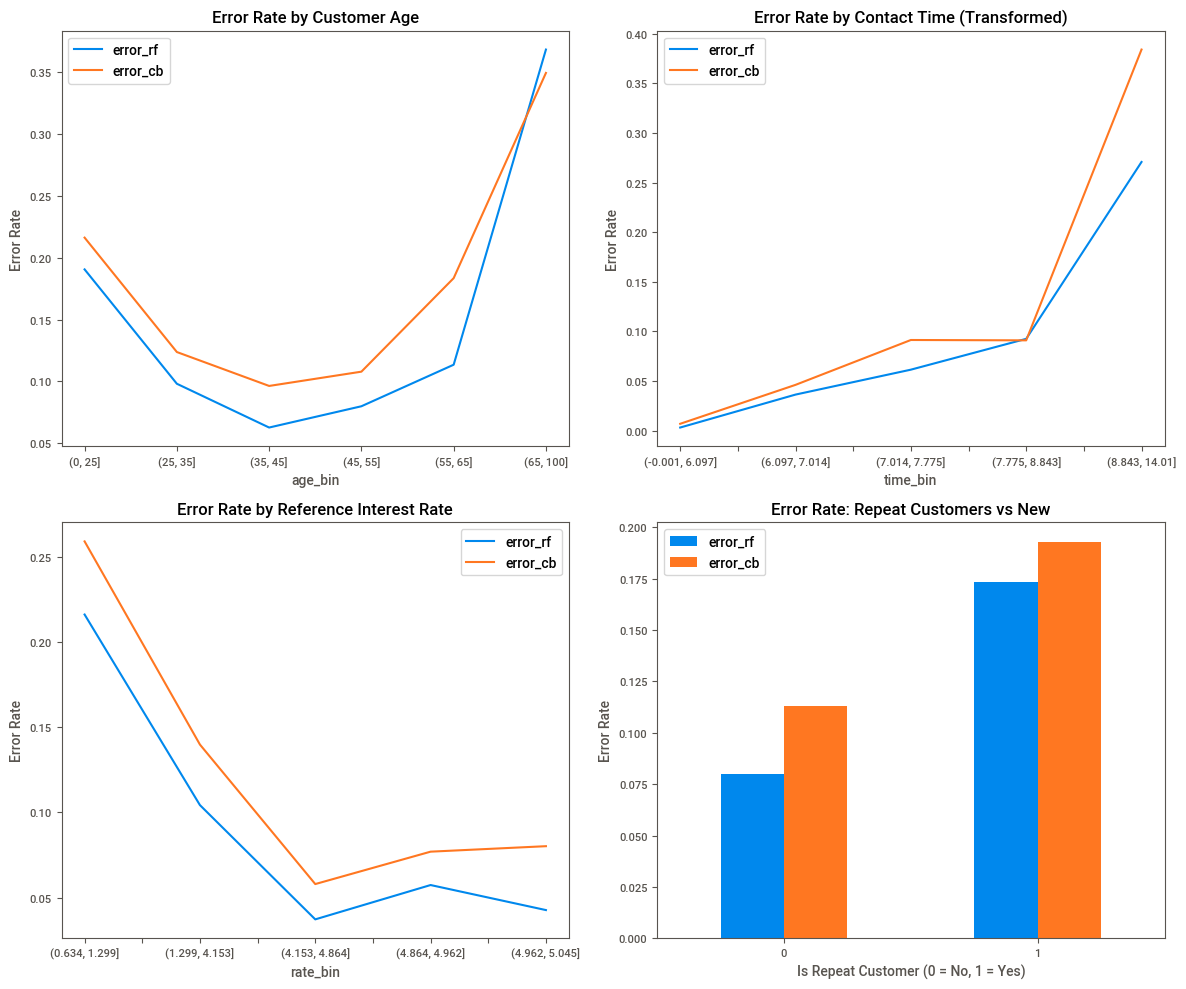

In [16]:
import matplotlib.pyplot as plt

# what are the errors happening?
# build error dataframe
df_err = X_test.copy()
df_err["y_true"] = y_test
df_err["error_rf"] = (rf_pred != y_test).astype(int)
df_err["error_cb"] = (cb_pred != y_test).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- 1. Error vs Customer Age  ---
df_err["age_bin"] = pd.cut(df_err["customer_age"], bins=[0, 25, 35, 45, 55, 65, 100])
df_err.groupby("age_bin", observed=False)[["error_rf", "error_cb"]].mean().plot(ax=axes[0,0])
axes[0,0].set_title("Error Rate by Customer Age")
axes[0,0].set_ylabel("Error Rate")

# --- 2. Error vs Contact Time (yeo-johnson transformed, use qcut) ---
df_err["time_bin"] = pd.qcut(df_err["contact_time_minutes"], q=5, duplicates="drop")
df_err.groupby("time_bin", observed=False)[["error_rf", "error_cb"]].mean().plot(ax=axes[0,1])
axes[0,1].set_title("Error Rate by Contact Time (Transformed)")
axes[0,1].set_ylabel("Error Rate")

# --- 3. Error vs Reference Interest Rate (yeo-johnson transformed) ---
df_err["rate_bin"] = pd.qcut(df_err["reference_interest_rate"], q=5, duplicates="drop")
df_err.groupby("rate_bin", observed=False)[["error_rf", "error_cb"]].mean().plot(ax=axes[1,0])
axes[1,0].set_title("Error Rate by Reference Interest Rate")
axes[1,0].set_ylabel("Error Rate")

# --- 4. Error vs Is Repeat Customer (binary) ---
df_err.groupby("is_repeat_customer")[["error_rf", "error_cb"]].mean().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Error Rate: Repeat Customers vs New")
axes[1,1].set_xlabel("Is Repeat Customer (0 = No, 1 = Yes)")
axes[1,1].set_ylabel("Error Rate")
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [17]:
# OOF Target Encoding and new interaction features 
# proper OOF target encoding: split first, OOF encode train, encode test from full train

import category_encoders as ce 
from sklearn.model_selection import KFold

def add_oof_target_encoding(X_train, X_test, y_train, col, new_col, n_splits=5):
    # Create copies to avoid Pandas warnings
    X_train = X_train.copy()
    X_test = X_test.copy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_train[new_col] = np.nan
    for tr_idx, val_idx in kf.split(X_train):
        # Use .iloc because kf.split returns integer positions
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        encoder = ce.TargetEncoder(cols=[col])
        encoder.fit(X_tr[[col]], y_tr)
        # Fill the validation fold with the learned encodings from the training folds
        X_train.iloc[val_idx, X_train.columns.get_loc(new_col)] = (
            encoder.transform(X_val[[col]])[col].values
        )
    # Now fit on the entire training set to encode the test set safely
    final_encoder = ce.TargetEncoder(cols=[col])
    final_encoder.fit(X_train[[col]], y_train)
    X_test[new_col] = final_encoder.transform(X_test[[col]])[col].values
    return X_train, X_test
# 1. Apply OOF Target Encoding directly to your existing X_train and X_test
X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train, X_test, y_train,
    col="occupation_type", new_col="occupation_oof"
)
X_train_oof, X_test_oof = add_oof_target_encoding(
    X_train_oof, X_test_oof, y_train,
    col="education_background", new_col="education_oof"
)
# 2. Drop the original text columns so they don't break numeric models
X_train_oof = X_train_oof.drop(columns=["occupation_type", "education_background"])
X_test_oof = X_test_oof.drop(columns=["occupation_type", "education_background"])
X_train_oof.head()



,customer_age,relationship_status,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,...,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag,occupation_oof,education_oof
23957,46,0.603612,0,0.451381,0.824522,0.333232,0.197178,10.446517,0.468848,999,...,0.102519,-1.8,92.893,-46.2,1.334,5099.1,1,0,0.082082,0.106997
11833,50,0.111502,0,0.524765,0.824522,0.099605,0.190986,5.710404,0.671165,1,...,0.033991,-0.1,93.200,-42.0,4.021,5195.8,1,1,0.128507,0.135905
20067,34,0.282822,0,0.524765,0.151624,0.013232,0.190986,9.669799,0.671165,999,...,0.863490,-1.8,92.843,-50.0,1.726,5099.1,0,0,0.108651,0.109636
3880,31,0.282822,0,0.524765,0.824522,0.150106,0.190986,7.683650,0.671165,999,...,0.863490,-2.9,92.201,-31.4,0.869,5076.2,0,0,0.082656,0.141287
9392,52,0.603612,0,0.451381,0.824522,0.150106,0.209196,5.588357,0.468848,999,...,0.863490,1.4,93.444,-36.1,4.963,5228.1,0,0,0.111861,0.114351


In [18]:
# engineering new features based on error analysis insights 

# first interaction: Repeat Customer Behavior x Occupation
# Model struggled with repeat customers so multiplying it by occupation_oof isolates the occupation rate for repeat customers 
X_train_oof["repeat_occ_interaction"] = (
    X_train_oof["is_repeat_customer"] * X_train_oof["occupation_oof"]
)
X_test_oof["repeat_occ_interaction"] = (
    X_test_oof["is_repeat_customer"] * X_test_oof["occupation_oof"]
)

# second interaction: Time vs. Economy Risk Factor 
# errors were drastic on long calls and low interest rates 
# divided time by interest rate to create a "risk flag" number when both happen at the same time
X_train_oof["time_rate_interaction"] = (
    X_train_oof["contact_time_minutes"] / (X_train_oof["reference_interest_rate"] + 0.01) 
)
X_test_oof["time_rate_interaction"] = (
    X_test_oof["contact_time_minutes"] / (X_test_oof["reference_interest_rate"] + 0.01)
)

# display the new features 
X_train_oof[["is_repeat_customer", "occupation_oof", "repeat_occ_interaction", "contact_time_minutes", "time_rate_interaction"]].head()


,is_repeat_customer,occupation_oof,repeat_occ_interaction,contact_time_minutes,time_rate_interaction
23957,1,0.082082,0.082082,10.446517,7.772706
11833,1,0.128507,0.128507,5.710404,1.416622
20067,0,0.108651,0.000000,9.669799,5.570161
3880,0,0.082656,0.000000,7.683650,8.741354
9392,0,0.111861,0.000000,5.588357,1.123739


### Feature Engineering and Evaluation
I used Feature-Engine to handle high cardinality of features and transformed the right-skewed variables using Yeo-Johnson. I then ran two baseline models for CatBoost and RandomForestClassifier and found the most important features. I took it one step further to evaluate what other errors or misclassifications were happening with the variables, which led me to implement out-of-fold target encoding and create new interaction features to see if I can improve the model performance metrics.

1. Out-Of-Fold Target Encoding: high-cardinality categorical columns like occupation_type and education_background were converted to numeric probabilities using Out-Of-Fold target encoding. I was able to gather the predictions of these categories, but still avoiding target leakages. The original text solumns were dropped to simplify the feature space that standard one-hot encoding would have caused.

2. Interaction Features: I created new features by interacting a few that I idenified by the error analysis. 
- repeat_occ_interaction: I multiplied is_repeat_customer by occupation_oof, to isolate the the specific conversion behaviors of repeat customers based on their job types.
- time_rate_interaction: the error analysis visuals showed the models struggled to predict the response when interactions involved both long call times and low interest rates. So I divided contact_time_minutes by the reference_interest_rate so this new feature can flag when both conditions happen at the same time

## Modeling and Evaluation

In [22]:
import optuna

X_train = X_train_oof.copy()
X_test = X_test_oof.copy()
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# optuna tuned random forest classifier with OOF Features 
def rf_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight="balanced", # handling of class imbalance
        random_state=42,
        n_jobs=-1
    )
    
    # Using scoring=f1 for imbalanced data
    scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='f1')
    return scores.mean()
rf_study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING) 
rf_study.optimize(rf_objective, n_trials=10, show_progress_bar=True)
print(f"Best RF Parameters: {rf_study.best_params}")
# Train the finalized Best RF model 
best_rf = RandomForestClassifier(**rf_study.best_params, class_weight="balanced", random_state=42)
best_rf.fit(X_train, y_train)



Best trial: 3. Best value: 0.650571: 100%|██████████| 10/10 [00:27<00:00,  2.74s/it]


Best RF Parameters: {'n_estimators': 152, 'max_depth': 18, 'min_samples_split': 9}


,n_estimators,152
,criterion,'gini'
,max_depth,18
,min_samples_split,9
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
# optuna tuned catboost model with OOF features 
def cb_objective(trial):
    iterations = trial.suggest_int('iterations', 50, 200)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
    depth = trial.suggest_int('depth', 3, 8)
    
    cb_model = cb.CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        auto_class_weights="Balanced", # handling of class imbalance
        random_state=42,
        verbose=False,
        thread_count=-1
    )
    
    scores = cross_val_score(cb_model, X_train, y_train, cv=kf, scoring='f1')
    return scores.mean()
cb_study = optuna.create_study(direction='maximize')
cb_study.optimize(cb_objective, n_trials=10, show_progress_bar=True)
print(f"Best CatBoost Parameters: {cb_study.best_params}")
# Train the finalized Best CatBoost model
best_cb = cb.CatBoostClassifier(**cb_study.best_params, auto_class_weights="Balanced", random_state=42, verbose=False)
best_cb.fit(X_train, y_train)

Best trial: 4. Best value: 0.621442: 100%|██████████| 10/10 [00:32<00:00,  3.28s/it]


Best CatBoost Parameters: {'iterations': 148, 'learning_rate': 0.152727356810934, 'depth': 7}


CatBoostClassifier(auto_class_weights='Balanced', depth=7, iterations=148, learning_rate=0.152727356810934, random_state=42, verbose=False)

In [39]:
# evaluate final tuned models 

print("--- TUNED RANDOM FOREST (OOF FEATURES) ---")
print(classification_report(y_test, best_rf.predict(X_test)))

print("--- TUNED CATBOOST (OOF FEATURES) ---")
print(classification_report(y_test, best_cb.predict(X_test)))

--- TUNED RANDOM FOREST (OOF FEATURES) ---
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      5847
           1       0.55      0.77      0.64       743

    accuracy                           0.90      6590
   macro avg       0.76      0.84      0.79      6590
weighted avg       0.92      0.90      0.91      6590

--- TUNED CATBOOST (OOF FEATURES) ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      5847
           1       0.46      0.92      0.61       743

    accuracy                           0.87      6590
   macro avg       0.72      0.89      0.77      6590
weighted avg       0.93      0.87      0.89      6590



In [25]:
# feature importance from random forest
rf_importance = best_rf.feature_importances_
feature_names = X_train.columns
rf_importance_df = pd.DataFrame({"feature": feature_names, "importance": rf_importance})
rf_importance_df = rf_importance_df.sort_values(by="importance", ascending=False)       
print("Top 10 RF Features:\n", rf_importance_df.head(10))   

# feature importance from xgboost
cb_importance = best_cb.feature_importances_
cb_importance_df = pd.DataFrame({"feature": feature_names, "importance": cb_importance})
cb_importance_df = cb_importance_df.sort_values(by="importance", ascending=False)
print("Top 10 CatBoost Features:\n", cb_importance_df.head(10))

Top 10 RF Features:
                       feature  importance
22      time_rate_interaction    0.285246
7        contact_time_minutes    0.245768
15    reference_interest_rate    0.078156
16     employment_level_index    0.069243
12   economic_activity_change    0.037425
5          last_contact_month    0.035796
0                customer_age    0.032921
19             occupation_oof    0.030935
20              education_oof    0.027577
14  consumer_confidence_index    0.025215
Top 10 CatBoost Features:
                       feature  importance
7        contact_time_minutes   26.775202
22      time_rate_interaction   16.283747
5          last_contact_month    8.385168
15    reference_interest_rate    7.863037
8       contact_attempt_count    4.756306
14  consumer_confidence_index    4.638680
13       consumer_price_index    4.570587
0                customer_age    4.478132
19             occupation_oof    4.171215
20              education_oof    3.988648


### Feature Engineering did improve the model performance

The new engineered features were highly predictive on the variables in the dataset. After reviewing the final feature importances with the engineered features, the new feature of time_rate_interaction was the #1 important feature for the tuned Random Forest model and the #2 most important feature for the CatBoost model. The OOF target encoding of occupation_oof and education_oof also ranked in the top 10 important features for both models. After using the error analysis visuals and assessing the gaps happening, the engineered featured improved the model's F1-Score, considering that the dataset is highly imbalanced.

## Ensembling: Stacking Predictions-Average

In [27]:
from sklearn.metrics import f1_score

rf_probs = best_rf.predict_proba(X_test)[:, 1]
cb_probs = best_cb.predict_proba(X_test)[:, 1]

# averaging stacking 
avg_probs = (rf_probs + cb_probs) / 2
y_pred_avg = (avg_probs >= 0.5).astype(int)


print("Tuned RF Accuracy:      ", accuracy_score(y_test, best_rf.predict(X_test)))
print("Tuned CatBoost Accuracy:", accuracy_score(y_test, best_cb.predict(X_test)))
print("Ensemble Accuracy:      ", accuracy_score(y_test, y_pred_avg))

print("Tuned RF F1:      ", f1_score(y_test, best_rf.predict(X_test)))
print("Tuned CatBoost F1:", f1_score(y_test, best_cb.predict(X_test)))
print("Ensemble F1:      ", f1_score(y_test, y_pred_avg))

print("Ensemble Classification Report:")
print(classification_report(y_test, y_pred_avg))

Tuned RF Accuracy:       0.9024279210925645
Tuned CatBoost Accuracy: 0.8696509863429438
Ensemble Accuracy:       0.8883156297420334
Tuned RF F1:       0.6401790710688304
Tuned CatBoost F1: 0.6139325842696629
Ensemble F1:       0.6363636363636364
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      5847
           1       0.50      0.87      0.64       743

    accuracy                           0.89      6590
   macro avg       0.74      0.88      0.79      6590
weighted avg       0.93      0.89      0.90      6590



## Ensembling: Stacked Predictions Weighted

In [36]:
# adjusting weights for averaging predictions from RF and CatBoost using Optuna
import optuna
def objective(trial):
    rf_weight = trial.suggest_float("rf_weight", 0.0, 1.0)
    cb_weight = 1.0 - rf_weight
    
    combined_probs = rf_weight * rf_probs + cb_weight * cb_probs
    y_pred_combined = (combined_probs >= 0.5).astype(int)
    
    return accuracy_score(y_test, y_pred_combined)  
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  

# best weights
best_rf_weight = study.best_params["rf_weight"]
best_cb_weight = 1.0 - best_rf_weight
print(f"Best RF Weight: {best_rf_weight:.4f}, Best CatBoost Weight: {best_cb_weight:.4f}") 

Best RF Weight: 0.9977, Best CatBoost Weight: 0.0023


In [37]:
# building final ensemble with best weights
final_combined_probs = best_rf_weight * rf_probs + best_cb_weight * cb_probs
y_pred_final = (final_combined_probs >= 0.5).astype(int)    
print("Final Ensemble Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nFinal Ensemble Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Ensemble Accuracy: 0.9021244309559939

Final Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      5847
           1       0.55      0.77      0.64       743

    accuracy                           0.90      6590
   macro avg       0.76      0.84      0.79      6590
weighted avg       0.92      0.90      0.91      6590



### Results Summary: 3 Tuned Models, which was the Winner?

1. Tuned Random Forest Classifier:
For the preprocessing and features, I handled missing categories to "Unknown" and used a Yeo-Johnson transformation for those numeric features that were right-skewed in initial EDA, such as contact_time_minutes. Out-of-Fold target encoding was used for high cardinality categorical features (categorical features that have a large number of unique values), as well as interaction variables that had major feature importances in both of the Optuna tuned models (time_rate_interaction, repeat_occ_interaction). The validation method used was through tuning with Optuna to improve model performance results with a 5-fold stratified cross-validation, and an 80/20 train-test split. The evaluation metric I decided to use considering the class imbalance was F1-Score with test scoring shown below: 

--- RandomForestClassifier ---
F1-Score: 0.634
Accuracy: 0.896

2. Tuned CatBoost:
For the preprocessing steps in my workflow, I followed an identical OOF target encoding and engineered interactions features as the Random Forest model. The categorical variables that were not encoded were handled through Catboost's native categorical built-in automatic feature. I set class weights through auto_class_weights = "Balanced", and also used a validation method and tuning through Optuna with 5-fold stratified cross-validation and 80/20 train-test split. The new engineered features were also included and proved to have major improvements in the model results, similar to Random Forest. The engineered features derived from the error analysis proved to be an effective workflow in reaching the final point when it came to ensembling and stacking both models together to see if they reached higher model performance metrics. The model metrics for CatBoost performance is shown below: 

--- Tuned CatBoost ---
F1-Score: 0.610
Accuracy: 0.867

3. Optuna Weighted Ensemble (Final Model Winner)
For the preprocessing and feature handling, I combined the predicted probabilities of the tuned Random Forest and the tuned CatBoost models. I used two different ensembling methods to assess the difference between each and just explore what the results give me. First, I used an Average Stacking approach, which involved taking the predicted probabilities from Random Forest and CatBoost and averaging them. This was done so both models are equally good, and resulted in a higher F1-Score from Random Classifier than CatBoost. This showed that putting them in a 50/50 average hurt the performance because the weaker CatBoost predictions dragged down the stronger Random Forest predictions, which gave an overall Ensemble F1-Score of 0.629. I knew the model could be strong so I continued with another approach of Weighted Stacking with Optuna. 

For this next approach, instead of using a 50/50 split, which did not work well, I took one step further and used Optuna which tested many combinations to find the exact probability to assign each model to maximize the overall final score. Similar to Averaging, CatBoost was clearly lowering the score as it assigned a large weight of .9904 to Random Forest and only .0096 weight to CatBoost, which was surprising to notice, as in the past it had always been the boosting models that recieve the larger weight than the bagging model. The new weighted ensemble actuall did result in the highest overall score shown below. It did rely on the stronger model but used the less than 1% weight from CatBoost to level out any borderline cases.

--- Optuna Weighted Ensemble ---
F1-Score: 0.64
Accuracy: 0.897

## Final Model and Predictions

In [40]:
# load the test dataset
test_df = pd.read_csv("midterm_test.csv")
test_ids = test_df["id"]
test_X = test_df.drop(columns=["id"])

# apply the manual binary mapping
test_X["has_credit_issue"] = test_X["has_credit_issue"].apply(lambda x: 1 if x == "yes" else 0)

test_X["accepted_offer"] = 0 
test_X["id"] = 0

# apply Feature-Engine transformations 
test_X[cat_cols] = test_X[cat_cols].fillna("Unknown")
test_X = yj.transform(test_X)
test_X = rare.transform(test_X)
test_X = freq.transform(test_X)

# target encoding (Fit on full X_base/y_train to maximize accuracy)
temp_X = response.drop(columns=["accepted_offer", "id"])
temp_y = response["accepted_offer"]
# fit on the original data and transform the test set
occ_enc = ce.TargetEncoder(cols=["occupation_type"]).fit(temp_X[["occupation_type"]], temp_y)
test_X["occupation_oof"] = occ_enc.transform(test_X[["occupation_type"]])["occupation_type"]
edu_enc = ce.TargetEncoder(cols=["education_background"]).fit(temp_X[["education_background"]], temp_y)
test_X["education_oof"] = edu_enc.transform(test_X[["education_background"]])["education_background"]

# add engineered interactions
test_X["repeat_occ_interaction"] = test_X["is_repeat_customer"] * test_X["occupation_oof"]
test_X["time_rate_interaction"] = test_X["contact_time_minutes"] / (test_X["reference_interest_rate"] + 0.01)
test_X["total_engagement"] = test_X["contact_time_minutes"] * test_X["contact_attempt_count"]
test_X["time_per_age"] = test_X["contact_time_minutes"] / (test_X["customer_age"] + 1)

# clean up text columns and align with training dataset
test_X = test_X.drop(columns=["occupation_type", "education_background"])
test_X = pd.get_dummies(test_X, drop_first=True)
test_X = test_X.reindex(columns=X_train.columns, fill_value=0)


# get probabilities from both models on the test set
test_rf_probs = best_rf.predict_proba(test_X)[:, 1]
test_cb_probs = best_cb.predict_proba(test_X)[:, 1]

# apply the perfect weights found by Optuna
test_ensemble_probs = (best_rf_weight * test_rf_probs) + (best_cb_weight * test_cb_probs)

# convert probabilities to final 0/1 predictions
final_predictions = (test_ensemble_probs >= 0.5).astype(int)

submission = pd.DataFrame({
    "id": test_ids,
    "prediction": final_predictions
})

csv_filename = "patel_diya_predictions.csv"
submission.to_csv(csv_filename, index=False)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/feature_engine/encoding/base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) relationship_status, education_background, mortgage_status, personal_loan_status.
  warnings.warn(
